In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'ColabNotebooks',
 'Fake.csv',
 'Fake.gsheet',
 'PCB_PROJECT',
 'PCB_DATASET_']

In [3]:
os.listdir('/content/drive/MyDrive/PCB_PROJECT')

['PCB_DATASET']

In [4]:
os.listdir('/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET')

['rotate.py', 'PCB_USED', 'images', 'Annotations', 'rotation']

In [5]:
os.listdir('/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/images')

['Spurious_copper',
 'Spur',
 'Open_circuit',
 'Short',
 'Mouse_bite',
 'Missing_hole']

**load one defect image**

Defect image: 11_short_01.jpg


(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

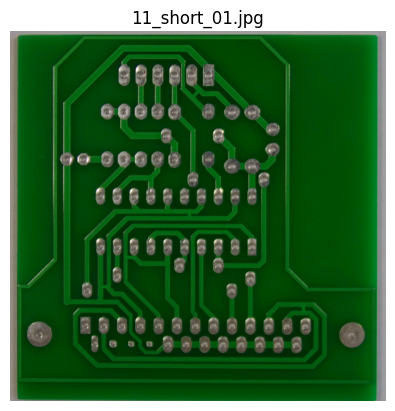

In [6]:
import cv2
import os
import matplotlib.pyplot as plt

DATASET_PATH = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET"

defect_folder = os.path.join(DATASET_PATH, "images", "Short")

img_name = os.listdir(defect_folder)[0]

print("Defect image:", img_name)

img_path = os.path.join(defect_folder, img_name)

defect_img = cv2.imread(img_path)

defect_img = cv2.cvtColor(defect_img, cv2.COLOR_BGR2RGB)

plt.imshow(defect_img)
plt.title(img_name)
plt.axis("off")

In [7]:
# Extract template number from filename

template_num = img_name.split("_")[0]

print("Template number:", template_num)

Template number: 11


**Load the template image**

Template path: /content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/PCB_USED/11.JPG


(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

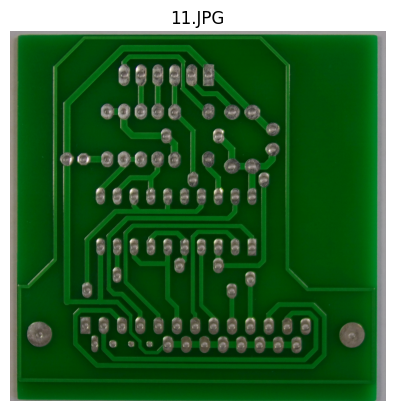

In [8]:
template_file = template_num + ".JPG"

template_path = os.path.join(DATASET_PATH, "PCB_USED", template_file)

print("Template path:", template_path)

template_img = cv2.imread(template_path)

template_img = cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)

plt.imshow(template_img)
plt.title(template_file)
plt.axis("off")

**convert images to grayscale**

(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

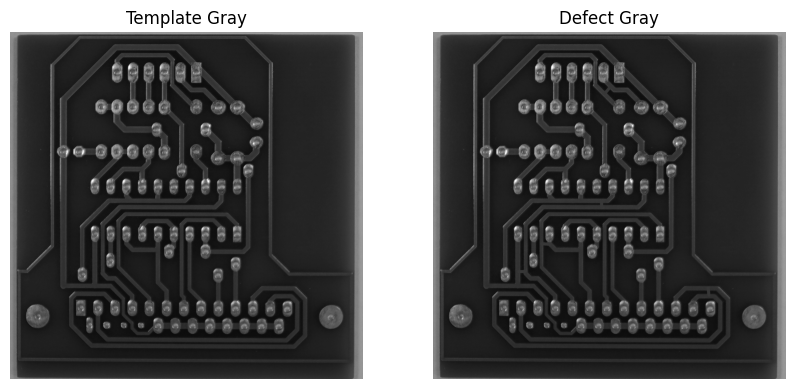

In [9]:
template_gray = cv2.cvtColor(template_img, cv2.COLOR_RGB2GRAY)
defect_gray = cv2.cvtColor(defect_img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(template_gray, cmap='gray')
plt.title("Template Gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(defect_gray, cmap='gray')
plt.title("Defect Gray")
plt.axis("off")

In [10]:
defect_gray = cv2.resize(
    defect_gray,
    (template_gray.shape[1], template_gray.shape[0])
)

print("Template shape:", template_gray.shape)
print("Defect shape:", defect_gray.shape)

Template shape: (2248, 2282)
Defect shape: (2248, 2282)


image subtraction

(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

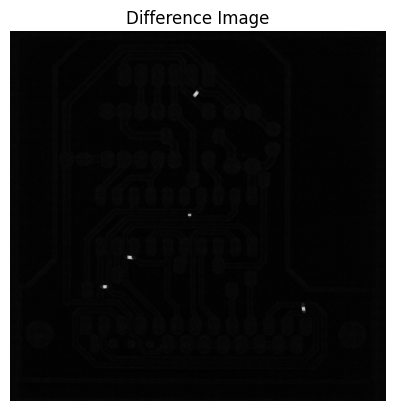

In [11]:
diff = cv2.absdiff(template_gray, defect_gray)

plt.imshow(diff, cmap='gray')
plt.title("Difference Image")
plt.axis("off")

remove noise

(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

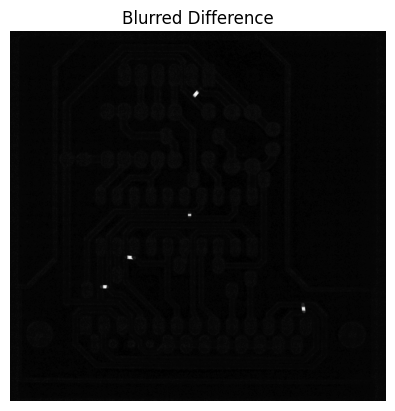

In [12]:
blur = cv2.GaussianBlur(diff, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Blurred Difference")
plt.axis("off")

(np.float64(-0.5), np.float64(2281.5), np.float64(2247.5), np.float64(-0.5))

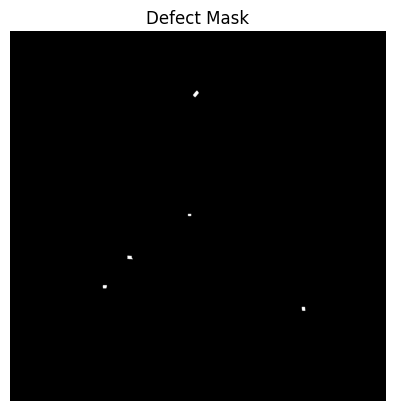

In [13]:
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(thresh, cmap='gray')
plt.title("Defect Mask")
plt.axis("off")